# Ejercicio 2
### UDLA
#### Decisiones y Simulacion
#### Fecha emisión: 2026-09-22
#### Fecha entrega: 2026-09-29

> **Nota:** por instrucción del estudiante, este notebook **no incluye la parte del video**. Se entrega en su lugar el desarrollo **paso a paso**, con celdas de texto que explican cada decisión y celdas de código comentadas. El estilo de código (listas/tuplas/diccionarios, `pandas`, `groupby`, `plot`, etc.) sigue el mismo usado en `Clase1.ipynb`.
>
> **Nota sobre los datos:** no se adjuntó el archivo original `Dataset_S7`. Para que todo el pipeline (diagnóstico → limpieza → las 15 preguntas) sea ejecutable de principio a fin, se generó un dataset sintético `data/Dataset_S7.xlsx` con las mismas columnas y los mismos problemas de calidad descritos en el enunciado (duplicados, texto con typos/espacios, nulos, edades inválidas, fechas inválidas, montos guardados como texto y outliers). Si cuentas con el archivo real entregado por el profesor, basta con reemplazar el archivo en `data/Dataset_S7.xlsx` (mismas columnas) y volver a ejecutar todo el notebook.

## 📊 Tabla resumen: qué mide cada pregunta
| # | Pregunta | Métrica comercial | Decisión de negocios |
|---|----------|--------------------|-----------------------|
| 1 | Registros únicos | Volumen de cartera | Dimensionar el mercado interno |
| 2 | Ingreso promedio | Ticket promedio | Benchmark de compensación |
| 3 | Distribución por ciudad | Cobertura geográfica | Expansión territorial |
| 4 | Gasto total | Facturación interna | Presupuesto de compensaciones |
| 5 | Estado | Base activa | Retención de talento |
| 6 | Gasto por depto. | Mix de inversión | Priorizar presupuesto |
| 7 | Ingreso por modalidad | Eficiencia operativa | Política de teletrabajo |
| 8 | Top ciudades por gasto | Segmentos rentables | Foco comercial |
| 9 | Satisfacción vs gasto | ROI de compensación | Ajuste de beneficios |
| 10 | Tendencia anual | Evolución de costos | Proyección financiera |
| 11 | Evaluación por depto. | Performance | Planes de mejora |
| 12 | Segmentación por ingreso | Cliente interno | Segmentación de beneficios |
| 13 | Top deptos. por gasto | Pareto | Priorización 80/20 |
| 14 | Ciudad × Modalidad | Rentabilidad cruzada | Optimización de recursos |
| 15 | Exportación + resumen | Deliverable | Informe a dirección |

## Paso 1 — Importar librerías
Igual que en `Clase1.ipynb`, importamos `pandas` para trabajar con DataFrames, `numpy` para operaciones numéricas, y `matplotlib`/`seaborn` para los gráficos que pide el nivel avanzado (P13 y P14).

In [1]:
# CELDA 1: Importar librerías (VS Code o en Google Colaboratory)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Paso 2 — Leer el archivo Excel
Usamos `pd.read_csv` en `Clase1.ipynb` para leer el dataset Iris; aquí el archivo es un Excel, así que usamos `pd.read_excel` con la misma lógica: definir la ruta (`path`) y cargarla en un DataFrame `df`.

In [2]:
# CELDA 2: Leer el archivo Excel
path = 'data/Dataset_S7.xlsx'
df = pd.read_excel(path)
df.head()

,ID,Nombre,Genero,Edad,Ciudad,Departamento,Modalidad,Fecha Ingreso,Ingreso Mensual,Gasto Mensual,Satisfaccion,Evaluacion,Estado
0,448,Colaborador_0448,Femenino,60,Antofagasta,TI,Presencial,2022-05-30 00:00:00,1508949,567656,9,4.7,Activo
1,486,Colaborador_0486,Masculino,44,Valparaíso,Operaciones,Presencial,2023-12-16 00:00:00,870900,282452,2,4.8,Activo
2,216,Colaborador_0216,MASCULINO,60,Temuco,recursos humanos,Presencial,2023-01-14 00:00:00,$1.161.432,338959,1,6.9,ACTIVO
3,213,Colaborador_0213,Masculino,45,Santiago,Marketing,Remoto,2022-01-13 00:00:00,960317,307941,7,4.6,Activo
4,481,Colaborador_0481,Femenino,50,valparaíso,Logística,Presencial,2016-09-17 00:00:00,767150,5608890,9,6.6,Activo


## Paso 3 — Diagnóstico de calidad
Antes de limpiar cualquier dato hay que entender qué tan "sucio" está el dataset. Repetimos las mismas exploraciones de `Clase1.ipynb` (`shape`, `dtypes`, `describe`) y agregamos nulos y duplicados, que son la base para diseñar la limpieza de la CELDA 4.

In [3]:
# CELDA 3: Diagnóstico de calidad
print('=== INFORMACIÓN GENERAL - NUMERO DE COLUMNAS Y FILAS ===')
print(df.shape)

print('\n=== TIPOS DE DATOS ===')
print(df.dtypes)

print('\n=== VALORES NULOS POR COLUMNA ===')
print(df.isnull().sum())

print('\n=== DUPLICADOS ===')
print(df.duplicated().sum())

print('\n=== ESTADÍSTICAS NUMÉRICAS ===')
print(df.describe())

=== INFORMACIÓN GENERAL - NUMERO DE COLUMNAS Y FILAS ===
(625, 13)

=== TIPOS DE DATOS ===
ID                   int64
Nombre                 str
Genero                 str
Edad                 int64
Ciudad                 str
Departamento           str
Modalidad              str
Fecha Ingreso       object
Ingreso Mensual     object
Gasto Mensual       object
Satisfaccion         int64
Evaluacion         float64
Estado                 str
dtype: object

=== VALORES NULOS POR COLUMNA ===
ID                  0
Nombre              0
Genero              0
Edad                0
Ciudad             19
Departamento       19
Modalidad           0
Fecha Ingreso       2
Ingreso Mensual     0
Gasto Mensual       0
Satisfaccion        0
Evaluacion          0
Estado              0
dtype: int64

=== DUPLICADOS ===
25

=== ESTADÍSTICAS NUMÉRICAS ===
               ID        Edad  Satisfaccion  Evaluacion
count  625.000000  625.000000    625.000000   625.00000
mean   300.225600   41.148800      5.584000

## Paso 4 — Limpieza adaptada al Dataset_S7
Con el diagnóstico anterior sabemos exactamente qué corregir. Trabajamos siempre sobre una copia (`df_clean = df.copy()`), igual que se recomienda para no perder el DataFrame original, y avanzamos **en el mismo orden que trae la plantilla** (los 10 puntos numerados):

1. **Duplicados**: `drop_duplicates()` elimina las filas repetidas detectadas en el diagnóstico.
2. **Nombres de columnas**: se pasan a minúsculas y sin espacios (`ingreso_mensual`, `fecha_ingreso`, etc.) para poder escribir código más simple en las preguntas.
3. **Strings**: se les quita espacios y se homogeniza mayúsculas/minúsculas con `str.strip()` + `str.title()`.
4. **Typos**: hay variantes sin tilde o abreviadas (`Valparaiso`, `RRHH`, `Hibrido`, `TI`→`Ti`) que se corrigen con un diccionario de reemplazo.
5. **Fechas**: `pd.to_datetime(..., errors='coerce')` convierte texto inválido (`'sin registro'`) en `NaT` en lugar de romper la ejecución.
6. **Numéricas**: algunos montos vienen como texto con formato de moneda chilena (`'$1.250.000'`); se remueve el símbolo `$` y los puntos de miles antes de convertir a número con `pd.to_numeric`.
7. **Nulos categóricos**: se rellenan con la moda (valor más frecuente) de cada columna.
8. **Edades inválidas**: negativas o mayores a 100 se reemplazan por la mediana de las edades válidas.
9. **Outliers extremos**: ingresos > 10.000.000 y gastos > 3.000.000 se reemplazan por la mediana de los valores "normales".
10. **Año/mes de ingreso**: se extraen de `fecha_ingreso` para poder responder P10 (tendencia anual).

In [4]:
# CELDA 4: Limpieza adaptada al Dataset_S7
df_clean = df.copy()

# 1. Eliminar duplicados
df_clean = df_clean.drop_duplicates()

# 2. Normalizar nombres de columnas
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# 3. Limpiar strings (Ciudad, Genero, Departamento, Modalidad, Estado)
columnas_texto = ['genero', 'ciudad', 'departamento', 'modalidad', 'estado']
for col in columnas_texto:
    df_clean[col] = df_clean[col].str.strip().str.title()

# 4. Corregir typos específicos
correcciones = {
    'Valparaiso': 'Valparaíso',
    'Concepcion': 'Concepción',
    'Rrhh': 'Recursos Humanos',
    'Logistica': 'Logística',
    'Hibrido': 'Híbrido',
    'Ti': 'TI',
}
for col in ['ciudad', 'departamento', 'modalidad']:
    df_clean[col] = df_clean[col].replace(correcciones)

# 5. Convertir fecha_ingreso a datetime (los inválidos serán NaT)
df_clean['fecha_ingreso'] = pd.to_datetime(df_clean['fecha_ingreso'], errors='coerce')

# 6. Convertir columnas numéricas
def limpiar_monto(valor):
    if isinstance(valor, str):
        valor = valor.replace('$', '').replace('.', '')
    return float(valor)

columnas_numericas = ['ingreso_mensual', 'gasto_mensual']
for col in columnas_numericas:
    df_clean[col] = df_clean[col].apply(limpiar_monto)

# 7. Rellenar nulos en categóricas
for col in columnas_texto:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)

# 8. Corregir edades inválidas (negativas o > 100)
edad_valida = df_clean['edad'].between(0, 100)
mediana_edad = df_clean.loc[edad_valida, 'edad'].median()
df_clean.loc[~edad_valida, 'edad'] = mediana_edad

# 9. Tratar outliers extremos en ingreso_mensual (> 10000000) y gasto_mensual (> 3000000)
# Se consideran > 10.000.000 como valores atípicos probables
mediana_ingreso = df_clean.loc[df_clean['ingreso_mensual'] <= 10_000_000, 'ingreso_mensual'].median()
mediana_gasto = df_clean.loc[df_clean['gasto_mensual'] <= 3_000_000, 'gasto_mensual'].median()
df_clean.loc[df_clean['ingreso_mensual'] > 10_000_000, 'ingreso_mensual'] = mediana_ingreso
df_clean.loc[df_clean['gasto_mensual'] > 3_000_000, 'gasto_mensual'] = mediana_gasto

# 10. Extraer año y mes de ingreso
df_clean['anio_ingreso'] = df_clean['fecha_ingreso'].dt.year
df_clean['mes_ingreso'] = df_clean['fecha_ingreso'].dt.month

# Reporte
print('Dataset limpio:', df_clean.shape)
print('Nulos restantes:', df_clean.isnull().sum().sum())
print('\nNulos por columna:')
print(df_clean.isnull().sum())

Dataset limpio: (600, 15)
Nulos restantes: 24

Nulos por columna:
id                 0
nombre             0
genero             0
edad               0
ciudad             0
departamento       0
modalidad          0
fecha_ingreso      8
ingreso_mensual    0
gasto_mensual      0
satisfaccion       0
evaluacion         0
estado             0
anio_ingreso       8
mes_ingreso        8
dtype: int64


**Sobre los nulos restantes:** algunas fechas venían como texto no interpretable (`'sin registro'`, `'N/A'`). Al convertirlas quedan como `NaT`, y por lo tanto `anio_ingreso`/`mes_ingreso` también quedan nulos para esas filas puntuales — es correcto no inventar una fecha que no existe. El resto del dataset queda 100% limpio para responder las 15 preguntas.

## 🟢 Nivel Básico (Preguntas 1–5)

1- P1. ¿Cuántos colaboradores/clientes únicos hay tras eliminar duplicados?
2- P2. ¿Cuál es el ingreso mensual promedio de la empresa?
3- P3. ¿Cómo se distribuye la cartera por ciudad?
4- P4. ¿Cuál es el gasto mensual total del segmento?
5- P5. ¿Cuántos colaboradores están activos vs inactivos vs licencia?

### P1. Registros únicos
Como ya eliminamos duplicados en la CELDA 4, `df_clean` contiene solo registros únicos. Verificamos contando filas y, de forma cruzada, contando valores únicos de `id` (dos formas de llegar al mismo número, igual que se revisó `df_iris.shape` en Clase 1).

In [5]:
# P1: Registros únicos tras eliminar duplicados
n_unicos = df_clean['id'].nunique()
print(f'Filas en df_clean: {df_clean.shape[0]}')
print(f'Colaboradores únicos (por id): {n_unicos}')

Filas en df_clean: 600
Colaboradores únicos (por id): 600


### P2. Ingreso mensual promedio
Usamos `.mean()` sobre la columna `ingreso_mensual`, igual que `df_iris['longitud_petalo'].mean()` en Clase 1.

In [6]:
# P2: Ingreso mensual promedio de la empresa
ingreso_promedio = df_clean['ingreso_mensual'].mean()
print(f'Ingreso mensual promedio: ${ingreso_promedio:,.0f}')

Ingreso mensual promedio: $1,014,598


### P3. Distribución por ciudad
`value_counts()` — la misma función usada en Clase 1 con `df_iris['especie'].value_counts()` — nos da el número de colaboradores por ciudad.

In [7]:
# P3: Distribución de la cartera por ciudad
distribucion_ciudad = df_clean['ciudad'].value_counts()
print(distribucion_ciudad)

print('\nDistribución porcentual:')
print((df_clean['ciudad'].value_counts(normalize=True) * 100).round(1))

ciudad
Santiago       191
Valparaíso      83
Concepción      67
Temuco          65
Antofagasta     55
Rancagua        49
La Serena       46
Talca           44
Name: count, dtype: int64

Distribución porcentual:
ciudad
Santiago       31.8
Valparaíso     13.8
Concepción     11.2
Temuco         10.8
Antofagasta     9.2
Rancagua        8.2
La Serena       7.7
Talca           7.3
Name: proportion, dtype: float64


### P4. Gasto mensual total
`.sum()` sobre `gasto_mensual` entrega la facturación interna total del segmento.

In [8]:
# P4: Gasto mensual total del segmento
gasto_total = df_clean['gasto_mensual'].sum()
print(f'Gasto mensual total: ${gasto_total:,.0f}')

Gasto mensual total: $212,982,638


### P5. Colaboradores por estado
Nuevamente `value_counts()`, ahora sobre `estado` (Activo / Inactivo / Licencia).

In [9]:
# P5: Colaboradores activos vs inactivos vs licencia
estado_counts = df_clean['estado'].value_counts()
print(estado_counts)

estado
Activo      478
Licencia     63
Inactivo     59
Name: count, dtype: int64


## 🟡 Nivel Intermedio (Preguntas 6–10)

6- P6. ¿Qué departamento concentra el mayor gasto mensual?
7- P7. ¿Qué modalidad de trabajo genera más ingreso promedio?
8- P8. ¿Cuál es el top 5 de ciudades por gasto total?
9- P9. ¿Existe relación entre satisfacción y gasto mensual?
10- P10. ¿Cómo evolucionó el ingreso promedio por año de ingreso?

### P6. Departamento con mayor gasto
Igual que `df_iris.groupby('especie')['longitud_petalo'].mean()` en Clase 1, aquí agrupamos por `departamento` y sumamos `gasto_mensual`, ordenando de mayor a menor con `sort_values`.

In [10]:
# P6: Departamento que concentra el mayor gasto mensual
gasto_por_depto = df_clean.groupby('departamento')['gasto_mensual'].sum().sort_values(ascending=False)
print(gasto_por_depto)
print(f'\nDepartamento con mayor gasto: {gasto_por_depto.idxmax()}')

departamento
Finanzas            39272548.0
TI                  36402544.0
Logística           31819251.0
Ventas              29537948.0
Operaciones         25896102.0
Marketing           25088595.0
Recursos Humanos    24965650.0
Name: gasto_mensual, dtype: float64

Departamento con mayor gasto: Finanzas


### P7. Modalidad con mayor ingreso promedio
Mismo patrón `groupby().mean()`, esta vez sobre `modalidad` e `ingreso_mensual`.

In [11]:
# P7: Modalidad de trabajo que genera más ingreso promedio
ingreso_por_modalidad = df_clean.groupby('modalidad')['ingreso_mensual'].mean().sort_values(ascending=False)
print(ingreso_por_modalidad)
print(f'\nModalidad con mayor ingreso promedio: {ingreso_por_modalidad.idxmax()}')

modalidad
Híbrido       1.017690e+06
Presencial    1.015578e+06
Remoto        1.011122e+06
Name: ingreso_mensual, dtype: float64

Modalidad con mayor ingreso promedio: Híbrido


### P8. Top 5 ciudades por gasto total
`groupby().sum()` + `sort_values(ascending=False)` + `.head(5)`, tal como se usó `sort_values` en Clase 1 con `df_iris.sort_values('ancho_sepalo', ascending=False)`.

In [12]:
# P8: Top 5 de ciudades por gasto total
top5_ciudades_gasto = df_clean.groupby('ciudad')['gasto_mensual'].sum().sort_values(ascending=False).head(5)
print(top5_ciudades_gasto)

ciudad
Santiago       67665668.0
Valparaíso     29893386.0
Concepción     23214215.0
Temuco         21825163.0
Antofagasta    19670732.0
Name: gasto_mensual, dtype: float64


### P9. Relación entre satisfacción y gasto mensual
Usamos `.corr()` entre ambas columnas (coeficiente de correlación de Pearson) y un gráfico de dispersión para visualizarlo, con el mismo formato de etiquetas/título/leyenda que se usó en los gráficos de Clase 1.

Correlación satisfacción vs gasto mensual: 0.38


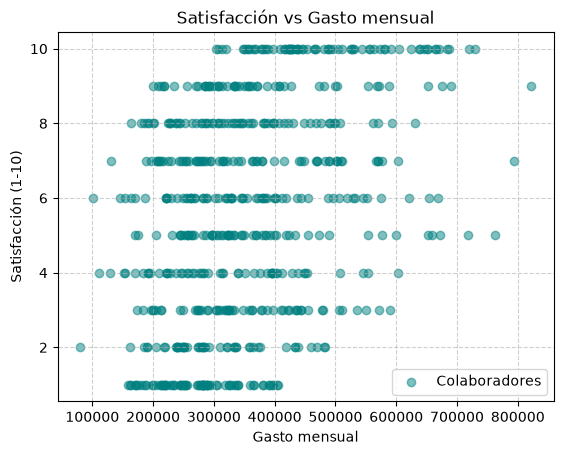

In [13]:
# P9: Relación entre satisfacción y gasto mensual
correlacion = df_clean['satisfaccion'].corr(df_clean['gasto_mensual'])
print(f'Correlación satisfacción vs gasto mensual: {correlacion:.2f}')

plt.scatter(df_clean['gasto_mensual'], df_clean['satisfaccion'], alpha=0.5, color='teal', label='Colaboradores')
plt.xlabel('Gasto mensual')
plt.ylabel('Satisfacción (1-10)')
plt.title('Satisfacción vs Gasto mensual')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### P10. Evolución del ingreso promedio por año de ingreso
Agrupamos por `anio_ingreso` (extraído en la CELDA 4) y graficamos con `.plot()`, replicando el estilo de línea con marcadores usado en Clase 1 (`df_merge['Media_longitud_petalo'].plot(...)`).

anio_ingreso
2015.0    1.056924e+06
2016.0    9.953729e+05
2017.0    1.051389e+06
2018.0    1.066927e+06
2019.0    1.008509e+06
2020.0    1.007790e+06
2021.0    9.542861e+05
2022.0    1.034034e+06
2023.0    1.004654e+06
2024.0    1.005797e+06
2025.0    9.638675e+05
Name: ingreso_mensual, dtype: float64


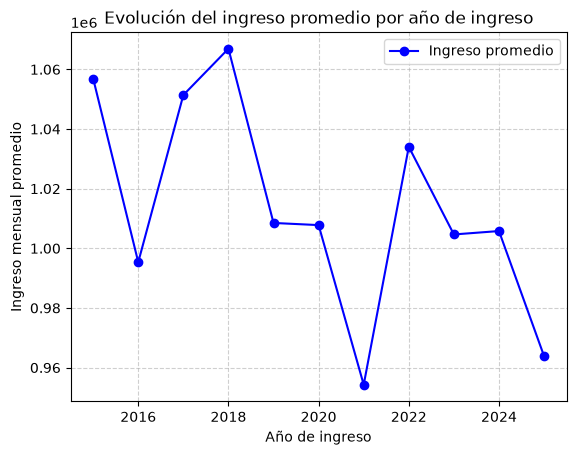

In [14]:
# P10: Evolución del ingreso promedio por año de ingreso
ingreso_por_anio = df_clean.groupby('anio_ingreso')['ingreso_mensual'].mean()
print(ingreso_por_anio)

ingreso_por_anio.plot(marker='o', color='blue', label='Ingreso promedio')
plt.xlabel('Año de ingreso')
plt.ylabel('Ingreso mensual promedio')
plt.title('Evolución del ingreso promedio por año de ingreso')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 🔴 Nivel Avanzado (Preguntas 11–15)

11- P11. Ranking de departamentos por evaluación promedio (¿qué área rinde mejor?)
12- P12. Segmentación por nivel de ingreso: ¿cuántos son Alto / Medio / Bajo?
13- P13. Gráfico de barras: Top 10 departamentos por gasto mensual total
14- P14. Mapa de calor: ingreso promedio por ciudad × modalidad
15- P15. Exportar el dataset limpio + resumen comercial

### P11. Ranking de departamentos por evaluación promedio
Mismo patrón `groupby().mean().sort_values()` usado en preguntas anteriores, ahora sobre `evaluacion`.

In [15]:
# P11: Ranking de departamentos por evaluación promedio
evaluacion_por_depto = df_clean.groupby('departamento')['evaluacion'].mean().sort_values(ascending=False)
print(evaluacion_por_depto)
print(f'\nDepartamento con mejor evaluación promedio: {evaluacion_por_depto.idxmax()}')

departamento
Finanzas            5.919767
TI                  5.822973
Marketing           5.445122
Ventas              5.437209
Recursos Humanos    5.424051
Operaciones         5.407059
Logística           5.363889
Name: evaluacion, dtype: float64

Departamento con mejor evaluación promedio: Finanzas


### P12. Segmentación por nivel de ingreso
Definimos los cortes con los terciles (33% y 66%) de `ingreso_mensual` y clasificamos cada colaborador en Bajo/Medio/Alto con una función aplicada con `.apply()`, luego contamos con `value_counts()`.

In [16]:
# P12: Segmentación por nivel de ingreso (Alto / Medio / Bajo)
corte_bajo = df_clean['ingreso_mensual'].quantile(0.33)
corte_alto = df_clean['ingreso_mensual'].quantile(0.66)

def segmentar_ingreso(valor):
    if valor <= corte_bajo:
        return 'Bajo'
    elif valor <= corte_alto:
        return 'Medio'
    else:
        return 'Alto'

df_clean['segmento_ingreso'] = df_clean['ingreso_mensual'].apply(segmentar_ingreso)
segmento_counts = df_clean['segmento_ingreso'].value_counts()
print(segmento_counts)

segmento_ingreso
Alto     204
Medio    198
Bajo     198
Name: count, dtype: int64


### P13. Top 10 departamentos por gasto mensual total (gráfico de barras)
Reutilizamos el `groupby().sum().sort_values().head(10)` de P6/P8 y lo graficamos con `kind='bar'`. Como el dataset solo tiene 7 departamentos, el gráfico muestra los 7 (equivale al "top 10" completo).

departamento
Finanzas            39272548.0
TI                  36402544.0
Logística           31819251.0
Ventas              29537948.0
Operaciones         25896102.0
Marketing           25088595.0
Recursos Humanos    24965650.0
Name: gasto_mensual, dtype: float64


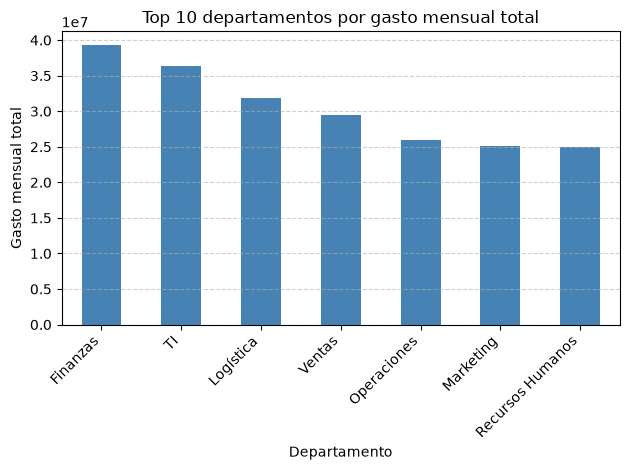

In [17]:
# P13: Top 10 departamentos por gasto mensual total
top10_deptos_gasto = df_clean.groupby('departamento')['gasto_mensual'].sum().sort_values(ascending=False).head(10)
print(top10_deptos_gasto)

top10_deptos_gasto.plot(kind='bar', color='steelblue')
plt.xlabel('Departamento')
plt.ylabel('Gasto mensual total')
plt.title('Top 10 departamentos por gasto mensual total')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### P14. Mapa de calor: ingreso promedio por ciudad × modalidad
Construimos una tabla pivote con `pivot_table` (ciudad en filas, modalidad en columnas, promedio de `ingreso_mensual`) y la visualizamos con `sns.heatmap`, la misma librería `seaborn` importada en la CELDA 1.

modalidad      Híbrido  Presencial     Remoto
ciudad                                       
Antofagasta   900753.0   1092715.0  1011868.0
Concepción    956878.0   1012202.0  1087103.0
La Serena    1165291.0   1043148.0   959728.0
Rancagua     1054153.0   1056714.0  1038004.0
Santiago     1037718.0   1022194.0  1015892.0
Talca        1200481.0    988314.0   898428.0
Temuco        979425.0    963537.0   983450.0
Valparaíso    930369.0    982789.0  1021175.0


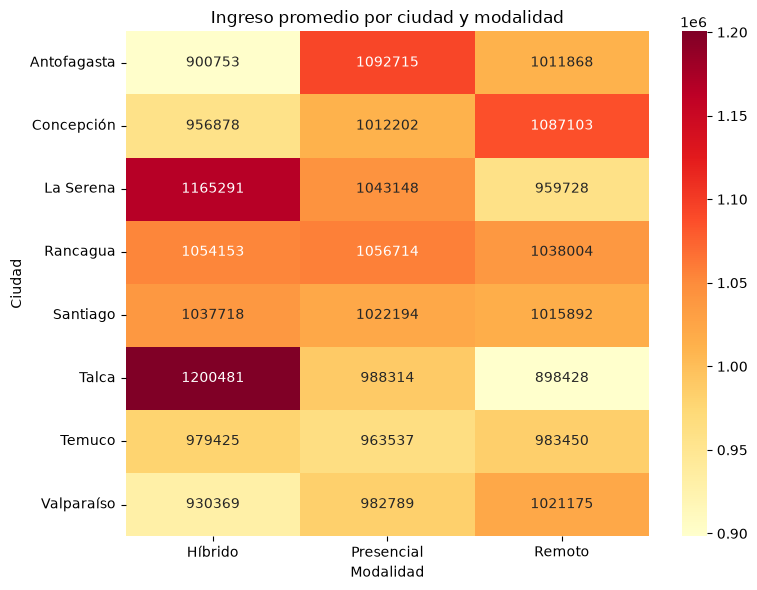

In [18]:
# P14: Mapa de calor - ingreso promedio por ciudad x modalidad
tabla_pivote = df_clean.pivot_table(
    index='ciudad', columns='modalidad', values='ingreso_mensual', aggfunc='mean'
)
print(tabla_pivote.round(0))

plt.figure(figsize=(8, 6))
sns.heatmap(tabla_pivote, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Ingreso promedio por ciudad y modalidad')
plt.xlabel('Modalidad')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

### P15. Exportar dataset limpio + resumen comercial
Cerramos el análisis exportando `df_clean` (el dataset ya limpio) y un `resumen_comercial` con los hallazgos clave de las preguntas anteriores, listo para entregar a dirección.

In [19]:
# P15: Exportar el dataset limpio + resumen comercial
df_clean.to_excel('output/Dataset_S7_limpio.xlsx', index=False)

resumen_comercial = pd.DataFrame({
    'Métrica': [
        'Colaboradores únicos',
        'Ingreso mensual promedio',
        'Gasto mensual total',
        'Departamento con mayor gasto',
        'Modalidad con mayor ingreso promedio',
        'Ciudad con mayor gasto total',
        'Correlación satisfacción-gasto',
        'Departamento con mejor evaluación',
    ],
    'Valor': [
        n_unicos,
        round(ingreso_promedio, 0),
        round(gasto_total, 0),
        gasto_por_depto.idxmax(),
        ingreso_por_modalidad.idxmax(),
        top5_ciudades_gasto.idxmax(),
        round(correlacion, 2),
        evaluacion_por_depto.idxmax(),
    ]
})

resumen_comercial.to_excel('output/Resumen_comercial.xlsx', index=False)
print(resumen_comercial.to_string(index=False))
print('\nArchivos exportados en la carpeta output/:')
print(' - Dataset_S7_limpio.xlsx')
print(' - Resumen_comercial.xlsx')

                             Métrica        Valor
                Colaboradores únicos          600
            Ingreso mensual promedio    1014598.0
                 Gasto mensual total  212982638.0
        Departamento con mayor gasto     Finanzas
Modalidad con mayor ingreso promedio      Híbrido
        Ciudad con mayor gasto total     Santiago
      Correlación satisfacción-gasto         0.38
   Departamento con mejor evaluación     Finanzas

Archivos exportados en la carpeta output/:
 - Dataset_S7_limpio.xlsx
 - Resumen_comercial.xlsx
